# Big Mart Sales Prediction (leakage-free version)

**What changed compared to the original notebook**

1. The data is split into **train / validation / test first**, before any imputation or encoding.
2. `Item_Weight` is imputed with a **model** (Linear Regression vs Random Forest with several hyperparameters) instead of the mean, and `Outlet_Size` with a **mode** (by outlet type). Both are learned **only from the training split**.
3. The sales model (Linear Regression vs Random Forest, several hyperparameters) is chosen on the **validation** set, and the **test** set is used only once at the very end.

## 1. Importing the dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn import metrics

SEED = 42
sns.set()

## 2. Data collection

In [3]:
DATA_PATH = 'sale/Train.csv'   # change this if your file is somewhere else
big_mart_data = pd.read_csv(DATA_PATH)
big_mart_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
print(big_mart_data.shape)
big_mart_data.info()

(8523, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [5]:
# missing values in the raw data
big_mart_data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

## 3. Row-wise cleaning (safe to do before splitting)

These two steps look at **one row at a time** (no mean / mode / statistics computed from other rows), so they cannot leak information between the splits.

In [6]:
# fix the inconsistent labels of Item_Fat_Content
big_mart_data['Item_Fat_Content'] = big_mart_data['Item_Fat_Content'].replace(
    {'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'})

# the first two letters of Item_Identifier are the broad category (FD = food, DR = drinks, NC = non-consumable)
big_mart_data['Item_Category'] = big_mart_data['Item_Identifier'].str[:2]

big_mart_data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

## 4. Split FIRST: train / validation / test (60 / 20 / 20)

Everything below (imputation models, encoders, sales model) is fitted on `train_df` only.

In [7]:
train_df, temp_df = train_test_split(big_mart_data, test_size=0.40, random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED)

train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
print('train:', train_df.shape, ' val:', val_df.shape, ' test:', test_df.shape)

train: (5113, 13)  val: (1705, 13)  test: (1705, 13)


## 5. Helper functions

`build_candidates` creates one Linear Regression and many Random Forests (every combination of the hyperparameter grid). Categorical columns are one-hot encoded inside a `Pipeline`, so the encoder is also fitted on the training rows only, and categories never seen in training are simply ignored.

In [8]:
def build_candidates(cat_cols, num_cols, rf_grid):
    def prep():
        return ColumnTransformer([
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', 'passthrough', num_cols),
        ])

    candidates = {'LinearRegression': Pipeline([('prep', prep()), ('model', LinearRegression())])}

    keys = list(rf_grid.keys())
    for values in product(*rf_grid.values()):
        params = dict(zip(keys, values))
        name = 'RF(' + ', '.join(f'{k}={v}' for k, v in params.items()) + ')'
        candidates[name] = Pipeline([
            ('prep', prep()),
            ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1, **params)),
        ])
    return candidates


def rmse(y_true, y_pred):
    return np.sqrt(metrics.mean_squared_error(y_true, y_pred))


def fit_and_rank(candidates, X_tr, y_tr, X_va, y_va):
    """Fit every candidate on the training part, score on the validation part, return the best one."""
    rows = []
    for name, pipe in candidates.items():
        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)
        rows.append({'model': name,
                     'val_RMSE': rmse(y_va, pred),
                     'val_R2': metrics.r2_score(y_va, pred)})
    results = pd.DataFrame(rows).sort_values('val_RMSE').reset_index(drop=True)
    best_model = candidates[results.loc[0, 'model']]
    return best_model, results

## 6. Imputing `Item_Weight` with a model

* Features: the columns that describe the **item** (`Item_Identifier`, `Item_Fat_Content`, `Item_Type`, `Item_Category`, `Item_MRP`, `Item_Visibility`). No outlet columns and **never the target** `Item_Outlet_Sales`.
* Rows of `train_df` with a known weight form the modelling data, and this is split 80% training / 20% validation.
* Rows of `train_df` with a missing weight are the "test" part of this sub-problem: they are what we predict.

In [9]:
weight_cat = ['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_Category']
weight_num = ['Item_MRP', 'Item_Visibility']
weight_features = weight_cat + weight_num

known_w = train_df[train_df['Item_Weight'].notna()]
print('train rows with known weight  :', len(known_w))
print('train rows with missing weight:', train_df['Item_Weight'].isna().sum())

w_train, w_val = train_test_split(known_w, test_size=0.20, random_state=SEED)

weight_rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 15],
    'min_samples_leaf': [1, 3],
    'max_features': [1.0],
}
weight_candidates = build_candidates(weight_cat, weight_num, weight_rf_grid)

weight_model, weight_results = fit_and_rank(
    weight_candidates,
    w_train[weight_features], w_train['Item_Weight'],
    w_val[weight_features], w_val['Item_Weight'])

print('\nBest Item_Weight model:', weight_results.loc[0, 'model'])
weight_results

train rows with known weight  : 4253
train rows with missing weight: 860

Best Item_Weight model: LinearRegression


,model,val_RMSE,val_R2
0,LinearRegression,1.578479,0.883153
1,"RF(n_estimators=200, max_depth=None, min_sampl...",2.573532,0.689401
2,"RF(n_estimators=100, max_depth=None, min_sampl...",2.588764,0.685713
3,"RF(n_estimators=200, max_depth=None, min_sampl...",3.292408,0.491644
4,"RF(n_estimators=100, max_depth=None, min_sampl...",3.301434,0.488852
5,"RF(n_estimators=100, max_depth=15, min_samples...",4.312913,0.127667
6,"RF(n_estimators=200, max_depth=15, min_samples...",4.325124,0.122720
7,"RF(n_estimators=100, max_depth=15, min_samples...",4.329363,0.121000
8,"RF(n_estimators=200, max_depth=15, min_samples...",4.337005,0.117894


In [11]:
# fill the missing weights in train, validation and test using the model chosen above
for df in (train_df, val_df, test_df):
    miss = df['Item_Weight'].isna()
    if miss.any():
        df.loc[miss, 'Item_Weight'] = weight_model.predict(df.loc[miss, weight_features])

print(train_df['Item_Weight'].isna().sum(), val_df['Item_Weight'].isna().sum(), test_df['Item_Weight'].isna().sum())

0 0 0


## 7. Imputing `Outlet_Size` with the mode

Simple rule: a missing size gets the **most common size among labelled outlets of the same `Outlet_Type`**, computed from the **training split only**. If a type has no labelled outlet, the overall mode is used. `Item_Outlet_Sales` is not used.

In [12]:
# modes from the labelled TRAINING rows only
known_rows = train_df[train_df['Outlet_Size'].notna()]
mode_fn = lambda s: s.mode().iloc[0]

mode_by_type = known_rows.groupby('Outlet_Type')['Outlet_Size'].agg(mode_fn).to_dict()
overall_mode = mode_fn(known_rows['Outlet_Size'])
print('mode of Outlet_Size per Outlet_Type:', mode_by_type)

# fill train, validation and test
for df in (train_df, val_df, test_df):
    miss = df['Outlet_Size'].isna()
    df.loc[miss, 'Outlet_Size'] = df.loc[miss, 'Outlet_Type'].map(mode_by_type).fillna(overall_mode)

print('missing after imputation:', train_df['Outlet_Size'].isna().sum(), val_df['Outlet_Size'].isna().sum(), test_df['Outlet_Size'].isna().sum())

# sanity check: size now assigned to each outlet (train split)
train_df.groupby(['Outlet_Identifier', 'Outlet_Type'])['Outlet_Size'].agg(lambda s: s.iloc[0])

mode of Outlet_Size per Outlet_Type: {'Grocery Store': 'Small', 'Supermarket Type1': 'Small', 'Supermarket Type2': 'Medium', 'Supermarket Type3': 'Medium'}
missing after imputation: 0 0 0


Outlet_Identifier  Outlet_Type      
OUT010             Grocery Store         Small
OUT013             Supermarket Type1      High
OUT017             Supermarket Type1     Small
OUT018             Supermarket Type2    Medium
OUT019             Grocery Store         Small
OUT027             Supermarket Type3    Medium
OUT035             Supermarket Type1     Small
OUT045             Supermarket Type1     Small
OUT046             Supermarket Type1     Small
OUT049             Supermarket Type1    Medium
Name: Outlet_Size, dtype: object

## 8. Quick data analysis (training split only, after imputation)

In [13]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,5113.000000,5113.000000,5113.000000,5113.000000,5113.000000
mean,12.996609,0.065934,142.514805,1997.956386,2220.464616
std,4.605036,0.051385,62.792654,8.385112,1727.634718
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.970000,0.026940,94.409400,1987.000000,852.224000
50%,12.850000,0.053951,144.476000,1999.000000,1822.294600
75%,17.000000,0.094512,187.255600,2004.000000,3131.923200
max,21.409661,0.328391,266.888400,2009.000000,13086.964800


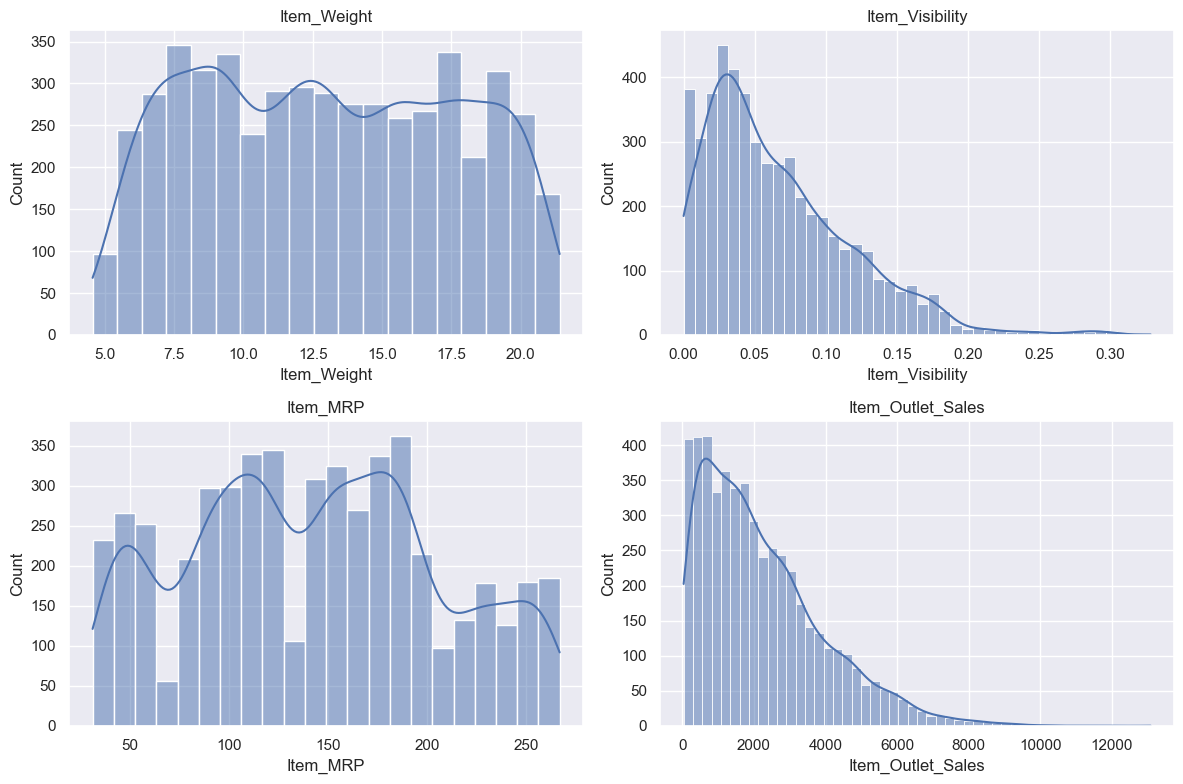

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Item_Outlet_Sales']):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

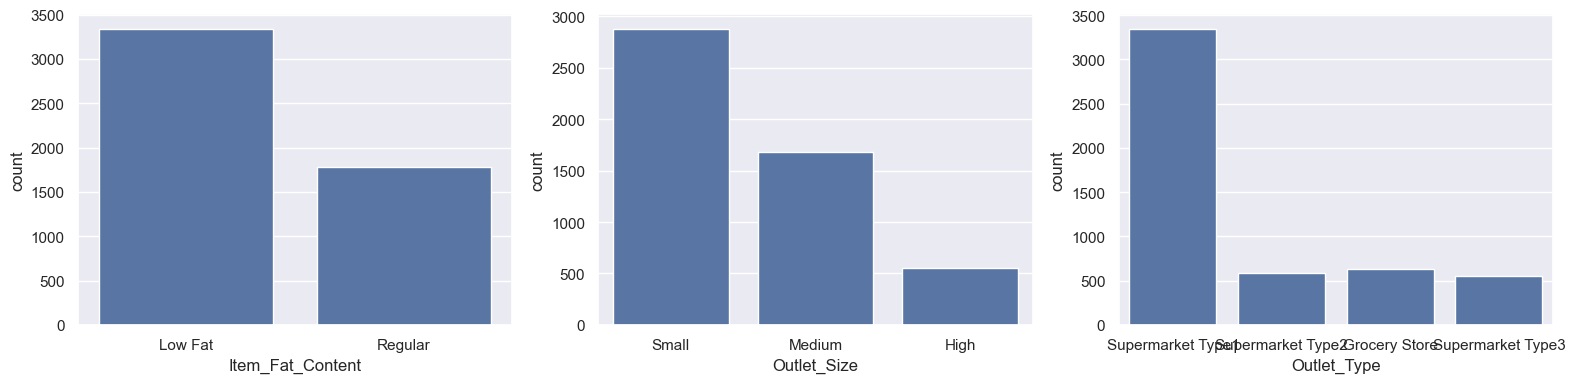

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x='Item_Fat_Content', data=train_df, ax=axes[0])
sns.countplot(x='Outlet_Size', data=train_df, ax=axes[1])
sns.countplot(x='Outlet_Type', data=train_df, ax=axes[2])
plt.tight_layout()
plt.show()

## 9. Sales model: Linear Regression vs Random Forest

* All columns are now complete, so we can build the final feature set. Categorical columns are one-hot encoded inside the pipeline (fitted on training rows only).
* `Item_Identifier` is left out here: it has ~1500 levels and would just let the models memorise items. The broad `Item_Category` (FD / DR / NC) is used instead.
* Model selection uses the **validation** set only. The test set is touched once, at the end.

In [16]:
sales_cat = ['Item_Fat_Content', 'Item_Type', 'Item_Category', 'Outlet_Identifier',
             'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
sales_num = ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
sales_features = sales_cat + sales_num
target = 'Item_Outlet_Sales'

X_train, y_train = train_df[sales_features], train_df[target]
X_val, y_val = val_df[sales_features], val_df[target]
X_test, y_test = test_df[sales_features], test_df[target]

sales_rf_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [1.0, 0.5],
}
sales_candidates = build_candidates(sales_cat, sales_num, sales_rf_grid)

best_sales_model, sales_results = fit_and_rank(sales_candidates, X_train, y_train, X_val, y_val)

print('Best sales model (chosen on validation):', sales_results.loc[0, 'model'])
sales_results.head(10)

Best sales model (chosen on validation): RF(n_estimators=300, max_depth=8, min_samples_leaf=1, max_features=0.5)


,model,val_RMSE,val_R2
0,"RF(n_estimators=300, max_depth=8, min_samples_...",1032.510368,0.610288
1,"RF(n_estimators=100, max_depth=8, min_samples_...",1033.968535,0.609186
2,"RF(n_estimators=300, max_depth=8, min_samples_...",1035.114856,0.608319
3,"RF(n_estimators=300, max_depth=8, min_samples_...",1035.437118,0.608075
4,"RF(n_estimators=300, max_depth=5, min_samples_...",1036.211381,0.607489
5,"RF(n_estimators=300, max_depth=8, min_samples_...",1036.463041,0.607298
6,"RF(n_estimators=100, max_depth=8, min_samples_...",1037.245598,0.606705
7,"RF(n_estimators=100, max_depth=5, min_samples_...",1037.430062,0.606565
8,"RF(n_estimators=100, max_depth=8, min_samples_...",1037.539461,0.606482
9,"RF(n_estimators=100, max_depth=8, min_samples_...",1037.748445,0.606324


In [17]:
# Linear Regression vs the best Random Forest on the validation set
sales_results[sales_results['model'].isin(['LinearRegression', sales_results.loc[sales_results['model'].str.startswith('RF'), 'model'].iloc[0]])]

,model,val_RMSE,val_R2
0,"RF(n_estimators=300, max_depth=8, min_samples_...",1032.510368,0.610288
48,LinearRegression,1074.675180,0.577808


## 10. Final evaluation

In [18]:
for split, X_s, y_s in [('train', X_train, y_train), ('validation', X_val, y_val), ('test', X_test, y_test)]:
    pred = best_sales_model.predict(X_s)
    print(f'{split:>10}:  R2 = {metrics.r2_score(y_s, pred):.4f}   RMSE = {rmse(y_s, pred):.2f}')

     train:  R2 = 0.6615   RMSE = 1005.08
validation:  R2 = 0.6103   RMSE = 1032.51
      test:  R2 = 0.5986   RMSE = 1071.24
